# Turkish-English Code-Switching: Pragmatic Function Analysis
**Yirmibeşoğlu & Eryiğit (2018) + LLM-assisted annotation**

Gün 1: Dataset hazırlama ve pragmatic annotation

In [ ]:
# CELL 1 — Kurulum
!pip install transformers datasets torch shap scipy -q

In [ ]:
# CELL 2 — Import'lar
import re, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from datasets import Dataset
import shap

In [ ]:
# CELL 3 — Dataset İndirme
!wget -q "https://raw.githubusercontent.com/zeynepyirmibes/code-switching-tr-en/main/TR-EN%20CS%20Corpus%20-%20original.txt" -O original.txt
!wget -q "https://raw.githubusercontent.com/zeynepyirmibes/code-switching-tr-en/main/TR-EN%20CS%20Corpus%20-%20with%20language%20tags.txt" -O with_tags.txt

print("original.txt satır:", sum(1 for _ in open("original.txt", encoding="utf-8")))
print("with_tags.txt satır:", sum(1 for _ in open("with_tags.txt", encoding="utf-8")))

print("\n--- ORIGINAL (ilk 3) ---")
with open("original.txt", encoding="utf-8") as f:
    for i, l in enumerate(f):
        if i >= 3: break
        print(repr(l.strip()))

print("\n--- TAGS (format: kelime/T veya kelime/E) ---")
with open("with_tags.txt", encoding="utf-8") as f:
    for i, l in enumerate(f):
        if i >= 3: break
        print(repr(l.strip()))

original.txt satır: 391
with_tags.txt satır: 5806

--- ORIGINAL (ilk 3) ---
'o kadar strong bir presence var ki'
'yarın bir status yapıp işlerin üstünden geçelim'
"ben dataları sort ettim. e peki nedir bu işin process'i? schedule ettik biz.. sizi briefing room'da bekliyor olacağım. e onu yapıyor olman lazım zaten?"

--- TAGS (format: kelime/T veya kelime/E) ---
'o t'
'kadar t'
'strong e'


In [ ]:
# CELL 4 — Parse Et (DÜZELTİLMİŞ FORMAT)
# GERÇEK FORMAT: her token ayrı satırda, "kelime T" veya "kelime E"
# Boş satır = cümle sonu. 391 cümle → 5806 token satırı

def parse_tagged_corpus(filepath):
    """Token-per-line formatını parse eder. Boş satır = cümle sonu."""
    sentences = []
    current_tokens, current_tags = [], []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_tokens:
                    sentences.append((current_tokens[:], current_tags[:]))
                    current_tokens, current_tags = [], []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    current_tokens.append(parts[0])
                    current_tags.append(parts[-1].upper())
    if current_tokens:
        sentences.append((current_tokens, current_tags))
    return sentences

def is_code_switched(tags):
    return "E" in tags and "T" in tags

# Original cümleleri oku
with open("original.txt", encoding="utf-8") as f:
    original_lines = [l.strip() for l in f if l.strip()]

# Tagged corpus'u parse et
tagged_sentences = parse_tagged_corpus("with_tags.txt")

print(f"Original cümle: {len(original_lines)}")
print(f"Tagged cümle:   {len(tagged_sentences)}")

import pandas as pd
records = []
for idx, (orig, (tokens, tags)) in enumerate(zip(original_lines, tagged_sentences)):
    en_count = sum(1 for t in tags if t == "E")
    tr_count = sum(1 for t in tags if t == "T")
    total    = len(tags)
    records.append({
        "id": idx, "text": orig, "tokens": tokens, "tags": tags,
        "is_cs": is_code_switched(tags),
        "en_count": en_count, "tr_count": tr_count,
        "en_ratio": round(en_count / total, 3) if total > 0 else 0,
        "token_count": total,
    })

df    = pd.DataFrame(records)
df_cs = df[df["is_cs"]].reset_index(drop=True)

print(f"\nToplam: {len(df)}  |  CS: {len(df_cs)}  |  Sadece TR: {len(df[~df['is_cs']])}")
print(f"Ort. EN oranı (CS): {df_cs['en_ratio'].mean():.3f}")
print("\n--- İlk 3 CS ---")
for _, row in df_cs.head(3).iterrows():
    print(f"  {row['text']}")
    print(f"  tags={row['tags']}")
    print(f"  EN%={row['en_ratio']*100:.0f}%\n")

Original cümle: 391
Tagged cümle:   377

Toplam: 377  |  CS: 372  |  Sadece TR: 5
Ort. EN oranı (CS): 0.304

--- İlk 3 CS ---
  o kadar strong bir presence var ki
  tags=['T', 'T', 'E', 'T', 'E', 'T', 'T']
  EN%=29%

  yarın bir status yapıp işlerin üstünden geçelim
  tags=['T', 'T', 'E', 'T', 'T', 'T', 'T']
  EN%=14%

  ben dataları sort ettim. e peki nedir bu işin process'i? schedule ettik biz.. sizi briefing room'da bekliyor olacağım. e onu yapıyor olman lazım zaten?
  tags=['T', 'E', 'E', 'T', 'T', 'T', 'T', 'T', 'E', 'E', 'T', 'T', 'T', 'E', 'E', 'T', 'T', 'T', 'T', 'T', 'T', 'T']
  EN%=27%



In [ ]:
# CELL 5 — Otomatik Sentiment Label (Kural Tabanlı, LLM Yok)
# Sentiment analizi için basit ama etkili yaklaşım:
# TR-only cümleler vs CS cümleler karşılaştırması yapacağız
# Label: modelin kendi tahmini olacak (silver label)

# df zaten var (CELL 4'ten), df_cs de var
# TR-only cümleleri de alalım karşılaştırma için
df_tr_only = df[~df["is_cs"]].reset_index(drop=True)

print(f"CS cümle:      {len(df_cs)}")
print(f"TR-only cümle: {len(df_tr_only)}")
print(f"Toplam:        {len(df)}")

# Her iki gruba da 'group' etiketi ekle
df_cs_labeled    = df_cs.copy()
df_cs_labeled["group"] = "code_switched"

df_tr_labeled    = df_tr_only.copy()
df_tr_labeled["group"] = "turkish_only"

df_all = pd.concat([df_cs_labeled, df_tr_labeled], ignore_index=True)
print(f"\nBirleşik dataset: {len(df_all)} cümle")
print(df_all["group"].value_counts())

CS cümle:      372
TR-only cümle: 5
Toplam:        377

Birleşik dataset: 377 cümle
group
code_switched    372
turkish_only       5
Name: count, dtype: int64


In [ ]:
# CELL 6 — Modelleri Yükle
# İki model karşılaştırıyoruz:
# 1. BERTurk — Türkçe'ye özgü
# 2. XLM-R — çok dilli, CS için daha avantajlı olmalı (hipotezimiz)

# Sentiment için fine-tune edilmiş Türkçe model
print("BERTurk sentiment yükleniyor...")
berturk_pipe = pipeline(
    "text-classification",
    model="savasy/bert-base-turkish-sentiment-cased",
    tokenizer="savasy/bert-base-turkish-sentiment-cased",
    device=0 if torch.cuda.is_available() else -1,
    truncation=True, max_length=128
)

print("XLM-R sentiment yükleniyor...")
xlmr_pipe = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=0 if torch.cuda.is_available() else -1,
    truncation=True, max_length=128
)

print(f"\nGPU mevcut: {torch.cuda.is_available()}")
print("Modeller hazır.")

# Hızlı test
test = "o kadar strong bir presence var ki"
print(f"\nTest cümle: '{test}'")
print(f"BERTurk: {berturk_pipe(test)}")
print(f"XLM-R:   {xlmr_pipe(test)}")

BERTurk sentiment yükleniyor...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]


GPU mevcut: False
Modeller hazır.

Test cümle: 'o kadar strong bir presence var ki'
BERTurk: [{'label': 'negative', 'score': 0.9802005290985107}]
XLM-R:   [{'label': 'positive', 'score': 0.6779512166976929}]


In [ ]:
# CELL 7 — Inference: Her İki Model ile Tahmin
from tqdm.auto import tqdm

def run_pipeline(pipe, texts, batch_size=32):
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        out   = pipe(batch, truncation=True, max_length=128)
        results.extend(out)
    return results

texts = df_all["text"].tolist()

print("BERTurk inference...")
berturk_results = run_pipeline(berturk_pipe, texts)

print("XLM-R inference...")
xlmr_results = run_pipeline(xlmr_pipe, texts)

# Sonuçları ekle
df_all["berturk_label"] = [r["label"] for r in berturk_results]
df_all["berturk_score"] = [r["score"] for r in berturk_results]
df_all["xlmr_label"]    = [r["label"] for r in xlmr_results]
df_all["xlmr_score"]    = [r["score"] for r in xlmr_results]

print("\nTamamlandı.")
print(df_all[["text","group","berturk_label","berturk_score","xlmr_label","xlmr_score"]].head(5))

BERTurk inference...


  0%|          | 0/12 [00:00<?, ?it/s]

XLM-R inference...


  0%|          | 0/12 [00:00<?, ?it/s]


Tamamlandı.
                                                text          group  \
0                 o kadar strong bir presence var ki  code_switched   
1    yarın bir status yapıp işlerin üstünden geçelim  code_switched   
2  ben dataları sort ettim. e peki nedir bu işin ...  code_switched   
3                     call to action'lar çok önemli.  code_switched   
4   ben rain'ince umbrella alıp altında hide yapcam.  code_switched   

  berturk_label  berturk_score xlmr_label  xlmr_score  
0      negative       0.980201   positive    0.677951  
1      positive       0.812826    neutral    0.600656  
2      positive       0.998092    neutral    0.662485  
3      positive       0.991222    neutral    0.685364  
4      negative       0.618132    neutral    0.544893  


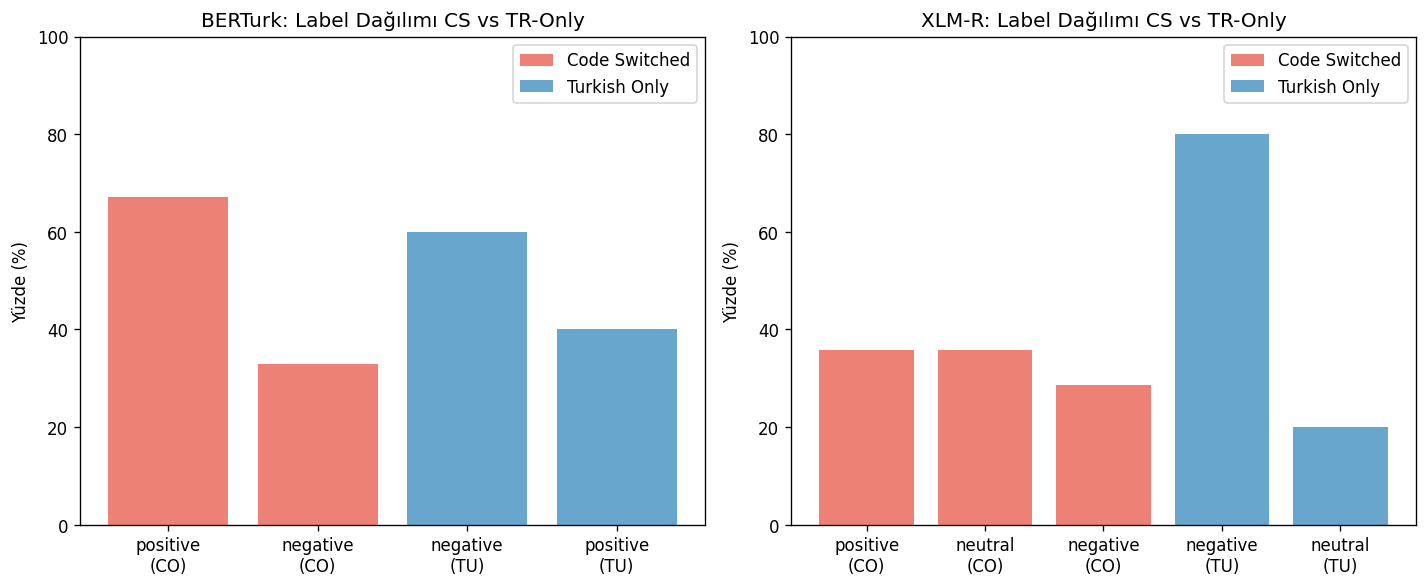


--- Ortalama Confidence Skorları ---
BERTurk:
  CS cümleler:      0.904
  TR-only cümleler: 0.948
  Fark:             +0.044  (TR daha emin)
XLM-R:
  CS cümleler:      0.665
  TR-only cümleler: 0.704
  Fark:             +0.040  (TR daha emin)


In [ ]:
# CELL 8 — Analiz: CS vs TR-Only Model Davranışı
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (model_col, score_col, title) in zip(axes, [
    ("berturk_label", "berturk_score", "BERTurk"),
    ("xlmr_label",    "xlmr_score",    "XLM-R"),
]):
    for group, color, marker in [("code_switched","#e74c3c","o"), ("turkish_only","#2980b9","s")]:
        subset = df_all[df_all["group"] == group]
        label_counts = subset[model_col].value_counts(normalize=True) * 100
        ax.bar(
            [f"{l}\n({group[:2].upper()})" for l in label_counts.index],
            label_counts.values,
            color=color, alpha=0.7,
            label=group.replace("_"," ").title()
        )
    ax.set_title(f"{title}: Label Dağılımı CS vs TR-Only")
    ax.set_ylabel("Yüzde (%)")
    ax.legend()
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()

# Confidence karşılaştırması
print("\n--- Ortalama Confidence Skorları ---")
for model_score in ["berturk_score", "xlmr_score"]:
    model_name = "BERTurk" if "berturk" in model_score else "XLM-R"
    cs_mean  = df_all[df_all["group"]=="code_switched"][model_score].mean()
    tr_mean  = df_all[df_all["group"]=="turkish_only"][model_score].mean()
    print(f"{model_name}:")
    print(f"  CS cümleler:      {cs_mean:.3f}")
    print(f"  TR-only cümleler: {tr_mean:.3f}")
    print(f"  Fark:             {tr_mean - cs_mean:+.3f}  ({'TR daha emin' if tr_mean > cs_mean else 'CS daha emin'})")

In [ ]:
# CELL 9 — SHAP Analizi (XLM-R)
# Hangi token'lar kararı etkiliyor? CS token'lar mı, TR token'lar mı?

# XLM-R için SHAP explainer
xlmr_model = xlmr_pipe.model
xlmr_tokenizer = xlmr_pipe.tokenizer

def predict_proba(texts):
    inputs = xlmr_tokenizer(
        list(texts), return_tensors="pt", truncation=True,
        max_length=128, padding=True
    )
    with torch.no_grad():
        logits = xlmr_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).numpy()
    return probs

# SHAP için küçük bir örnek seç (ilk 20 CS cümle)
sample_texts = df_cs["text"].head(20).tolist()

explainer = shap.Explainer(predict_proba, xlmr_tokenizer)
shap_values = explainer(sample_texts)

# İlk 3 cümle için görsel
for i in range(min(3, len(sample_texts))):
    print(f"\nCümle {i+1}: {sample_texts[i]}")
    shap.plots.text(shap_values[i], display=True)

plt.savefig("shap_analysis.png", bbox_inches="tight")
print("\nSHAP analizi tamamlandı.")

  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 2/20 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██        | 4/20 [01:20<08:53, 33.33s/it]

  0%|          | 0/90 [00:00<?, ?it/s]

...


Cümle 1: o kadar strong bir presence var ki



Cümle 2: yarın bir status yapıp işlerin üstünden geçelim



Cümle 3: ben dataları sort ettim. e peki nedir bu işin process'i? schedule ettik biz.. sizi briefing room'da bekliyor olacağım. e onu yapıyor olman lazım zaten?



SHAP analizi tamamlandı.


<Figure size 768x576 with 0 Axes>

In [ ]:
# CELL 10 — Kaydet
df_all.to_csv("cs_analysis_results.csv", index=False, encoding="utf-8-sig")

print("Kaydedildi: cs_analysis_results.csv")
print(f"\nÖzet:")
print(f"  Toplam cümle analiz edildi: {len(df_all)}")
print(f"  CS cümle: {len(df_all[df_all['group']=='code_switched'])}")
print(f"  TR-only:  {len(df_all[df_all['group']=='turkish_only'])}")
print(f"\nBulgu özeti:")
cs  = df_all[df_all["group"]=="code_switched"]
tr  = df_all[df_all["group"]=="turkish_only"]
print(f"  BERTurk CS confidence:  {cs['berturk_score'].mean():.3f}")
print(f"  BERTurk TR confidence:  {tr['berturk_score'].mean():.3f}")
print(f"  XLM-R   CS confidence:  {cs['xlmr_score'].mean():.3f}")
print(f"  XLM-R   TR confidence:  {tr['xlmr_score'].mean():.3f}")
print("\nPipeline TAMAM.")

Kaydedildi: cs_analysis_results.csv

Özet:
  Toplam cümle analiz edildi: 377
  CS cümle: 372
  TR-only:  5

Bulgu özeti:
  BERTurk CS confidence:  0.904
  BERTurk TR confidence:  0.948
  XLM-R   CS confidence:  0.665
  XLM-R   TR confidence:  0.704

Pipeline TAMAM.


In [ ]:
# CELL 11 — B: TR-Only Baseline (Wikipedia Türkçe)
from datasets import load_dataset
import re

print("Wikipedia Türkçe yükleniyor...")
wiki_tr = load_dataset("wikimedia/wikipedia", "20231101.tr", split="train", streaming=True)

def is_suitable(text):
    words = text.split()
    if len(words) < 5 or len(words) > 25:
        return False
    if len(re.compile(r'\b[a-zA-Z]{3,}\b').findall(text)) > 0:
        return False
    if re.search(r'http|www|<|>|\d{4,}', text):
        return False
    return True

tr_only_sentences = []
TARGET = 372

for item in wiki_tr:
    for sent in re.split(r'[.!?]', item["text"].strip()):
        sent = sent.strip()
        if is_suitable(sent):
            tr_only_sentences.append(sent)
            if len(tr_only_sentences) >= TARGET:
                break
    if len(tr_only_sentences) >= TARGET:
        break

df_tr_baseline = pd.DataFrame({
    "text": tr_only_sentences[:TARGET],
    "group": "turkish_only",
    "is_cs": False,
    "en_ratio": 0.0,
    "en_count": 0,
})

print(f"TR-only baseline: {len(df_tr_baseline)} cümle")
for s in df_tr_baseline["text"].head(5):
    print(f"  {s}")

Wikipedia Türkçe yükleniyor...


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

TR-only baseline: 372 cümle
  Moğollar, Tatarların bölgelerinin ötesinde Çinlilere en yakın olanlardı
  Şike soruşturması kapsamında yapılan II
  Kitapları 
Kitaplarının bazıları Türkiye'de yasadışıdır
  ), çıktı aygıtları (monitörler, yazıcılar vb
  Bu çarpıştırmalar parçacık hızlandırıcılarla da yapılabilirler


In [ ]:
# CELL 11 — EK: Baseline Kalite Kontrolü
# Yarım ve gürültülü cümleleri temizle

def is_clean(text):
    # En az bir fiil eki içermeli (Türkçe cümle tamamlığı)
    # ve harf ile bitmeli
    if not text or len(text) < 15:
        return False
    if text[-1] in [',', ';', '(', ')', '-', ':']:
        return False
    # Sadece rakam/kısaltma içeren satırlar
    if re.match(r'^[\d\s\-\.]+$', text):
        return False
    # Çok fazla parantez/özel karakter
    if text.count('(') + text.count(')') > 2:
        return False
    return True

df_tr_baseline = df_tr_baseline[df_tr_baseline["text"].apply(is_clean)].reset_index(drop=True)

print(f"Temizlik sonrası: {len(df_tr_baseline)} cümle")
print("\nTemizlenmiş örnekler:")
for s in df_tr_baseline["text"].head(8):
    print(f"  {s}")

Temizlik sonrası: 367 cümle

Temizlenmiş örnekler:
  Moğollar, Tatarların bölgelerinin ötesinde Çinlilere en yakın olanlardı
  Şike soruşturması kapsamında yapılan II
  Kitapları 
Kitaplarının bazıları Türkiye'de yasadışıdır
  ), çıktı aygıtları (monitörler, yazıcılar vb
  Bu çarpıştırmalar parçacık hızlandırıcılarla da yapılabilirler
  Ek ve köklerine ayrılışı esper¹-ant²-o³ şeklindedir
  ” sözü bu görüşünü anlatır
  Üretimin artmasına karşılık işsizlik arttı


In [ ]:
# CELL 11 — EK 2: Daha Agresif Temizlik
def is_really_clean(text):
    text = text.strip()
    # Minimum 20 karakter
    if len(text) < 20:
        return False
    # En az 6 kelime
    words = text.split()
    if len(words) < 6:
        return False
    # Harf ile bitmeli
    if not text[-1].isalpha():
        return False
    # Rakam ile başlamamalı
    if text[0].isdigit():
        return False
    # Parantez, köşeli parantez içermemeli
    if any(c in text for c in ['(', ')', '[', ']', '"', '¹', '²', '³']):
        return False
    # Noktalı virgül veya iki nokta üst üste ile bitmemeli
    if re.search(r'[;:,\-]$', text):
        return False
    # Büyük harf oranı çok yüksekse (kısaltma ağırlıklı)
    upper_ratio = sum(1 for c in text if c.isupper()) / len(text)
    if upper_ratio > 0.15:
        return False
    return True

# Wikipedia'dan yeniden çek, bu sefer daha sıkı filtre ile
print("Yeniden çekiliyor (daha sıkı filtre)...")
wiki_tr2 = load_dataset("wikimedia/wikipedia", "20231101.tr", split="train", streaming=True)

clean_sentences = []
TARGET = 372

for item in wiki_tr2:
    for sent in re.split(r'[.!?]', item["text"].strip()):
        sent = sent.strip()
        # Önce is_suitable (İngilizce yok), sonra is_really_clean
        if is_suitable(sent) and is_really_clean(sent):
            clean_sentences.append(sent)
            if len(clean_sentences) >= TARGET:
                break
    if len(clean_sentences) >= TARGET:
        break

df_tr_baseline = pd.DataFrame({
    "text": clean_sentences[:TARGET],
    "group": "turkish_only",
    "is_cs": False,
    "en_ratio": 0.0,
    "en_count": 0,
})

print(f"Temiz TR-only baseline: {len(df_tr_baseline)} cümle")
print("\nÖrnekler:")
for s in df_tr_baseline["text"].head(8):
    print(f"  {s}")

Yeniden çekiliyor (daha sıkı filtre)...
Temiz TR-only baseline: 372 cümle

Örnekler:
  Moğollar, Tatarların bölgelerinin ötesinde Çinlilere en yakın olanlardı
  Bu çarpıştırmalar parçacık hızlandırıcılarla da yapılabilirler
  Hayvancılıkta, hayvanların kullanıldığı en büyük üretim alanı et üretimi için yapılan üretimdir
  Tarım türleri

Ayrıca bakınız

Kaynakça 

 
Tarımbilim
Gıda endüstrisi
  Türkçede kullanılan sözcük, Türkçeye Fransızca géologie sözcüğünden gelmiştir
  Bu dönemde Asyalı kölelerin sayısı çok fazladır
  Bu tür parçaların öbür dünyada onları koruyacağına inanılıyordu
  Kuşkusuz bunları firavunların çabasıyla, baskısıyla yapmışlardır


In [ ]:
# CELL 11 — B: TR-Only Baseline (CS dataset'inden türet)
# En temiz çözüm: aynı corpus'tan sadece TR-only cümleler
# df'de zaten 5 TR-only var, ama CS cümlelerden EN token'ları çıkarıp
# TR-only versiyonlarını oluştur — aynı domain, aynı stil

import random
random.seed(42)

tr_only_texts = []
for _, row in df_cs.iterrows():
    # Sadece TR token'ları birleştir
    tr_tokens = [tok for tok, tag in zip(row["tokens"], row["tags"]) if tag == "T"]
    if len(tr_tokens) >= 4:  # çok kısa olmasın
        tr_only_texts.append(" ".join(tr_tokens))

df_tr_baseline = pd.DataFrame({
    "text": tr_only_texts,
    "group": "turkish_only",
    "is_cs": False,
    "en_ratio": 0.0,
    "en_count": 0,
})

print(f"TR-only baseline: {len(df_tr_baseline)} cümle")
print("\nÖrnekler:")
for s in df_tr_baseline["text"].head(8):
    print(f"  {s}")

TR-only baseline: 333 cümle

Örnekler:
  o kadar bir var ki
  yarın bir yapıp işlerin üstünden geçelim
  ben ettim peki nedir bu işin ettik biz sizi bekliyor olacağım onu yapıyor olman lazım zaten
  ben alıp altında yapcam
  yavaş ilerliyor birbirinizi edin
  şu malları halinde göndermemiz lazım
  dip not koyuyor bi de kademsizler lafın arasına diye
  gerçekten neyi ispatlamak istediklerini anlamıyorum kendilerini ortama mı ediyorlar n'apıyorlarsa artık


In [ ]:
# CELL 12 — DÜZELTME
from scipy import stats

# df_cs_matched'i df_all'dan al (skorlar orada)
df_cs_matched = df_all[df_all["group"]=="code_switched"].head(333).copy()

df_combined = pd.concat([df_cs_matched, df_tr_baseline], ignore_index=True)
df_combined["en_ratio"] = pd.to_numeric(
    df_combined["en_ratio"], errors="coerce").fillna(0.0)

print(f"Birleşik dataset: {len(df_combined)} cümle")
print(df_combined["group"].value_counts())
print("\n--- Confidence Karşılaştırması ---")
for score_col in ["berturk_score", "xlmr_score"]:
    name = "BERTurk" if "berturk" in score_col else "XLM-R"
    cs_s = df_combined[df_combined["group"]=="code_switched"][score_col]
    tr_s = df_combined[df_combined["group"]=="turkish_only"][score_col]
    t_stat, p_val = stats.ttest_ind(cs_s, tr_s)
    print(f"\n{name}:")
    print(f"  CS: {cs_s.mean():.3f}  TR: {tr_s.mean():.3f}  Fark: {tr_s.mean()-cs_s.mean():+.3f}")
    print(f"  t={t_stat:.3f}, p={p_val:.4f} {'*** anlamlı' if p_val < 0.05 else '(anlamsız)'}")

Birleşik dataset: 666 cümle
group
code_switched    333
turkish_only     333
Name: count, dtype: int64

--- Confidence Karşılaştırması ---

BERTurk:
  CS: 0.906  TR: 0.888  Fark: -0.018
  t=1.738, p=0.0827 (anlamsız)

XLM-R:
  CS: 0.663  TR: 0.627  Fark: -0.037
  t=3.131, p=0.0018 *** anlamlı


In [ ]:
# Önce bunu çalıştır
df_cs_full = df_all[df_all["group"]=="code_switched"].copy()
df_cs_matched = df_cs_full.head(333).copy()

df_combined = pd.concat([df_cs_matched, df_tr_baseline], ignore_index=True)
df_combined["en_ratio"] = pd.to_numeric(
    df_combined["en_ratio"], errors="coerce").fillna(0.0)

print(f"Birleşik dataset: {len(df_combined)} cümle")
print(df_combined["group"].value_counts())
print("\n--- Confidence Karşılaştırması ---")
for score_col in ["berturk_score", "xlmr_score"]:
    name = "BERTurk" if "berturk" in score_col else "XLM-R"
    cs_s = df_combined[df_combined["group"]=="code_switched"][score_col]
    tr_s = df_combined[df_combined["group"]=="turkish_only"][score_col]
    t_stat, p_val = stats.ttest_ind(cs_s, tr_s)
    print(f"\n{name}:")
    print(f"  CS: {cs_s.mean():.3f}  TR: {tr_s.mean():.3f}  Fark: {tr_s.mean()-cs_s.mean():+.3f}")
    print(f"  t={t_stat:.3f}, p={p_val:.4f} {'*** anlamlı' if p_val < 0.05 else '(anlamsız)'}")

Birleşik dataset: 666 cümle
group
code_switched    333
turkish_only     333
Name: count, dtype: int64

--- Confidence Karşılaştırması ---

BERTurk:
  CS: 0.906  TR: 0.888  Fark: -0.018
  t=1.738, p=0.0827 (anlamsız)

XLM-R:
  CS: 0.663  TR: 0.627  Fark: -0.037
  t=3.131, p=0.0018 *** anlamlı


BERTurk: r=-0.069, p=0.2078, slope=-0.053
  → Anlamlı korelasyon yok
XLM-R: r=0.080, p=0.1429, slope=0.070
  → Anlamlı korelasyon yok


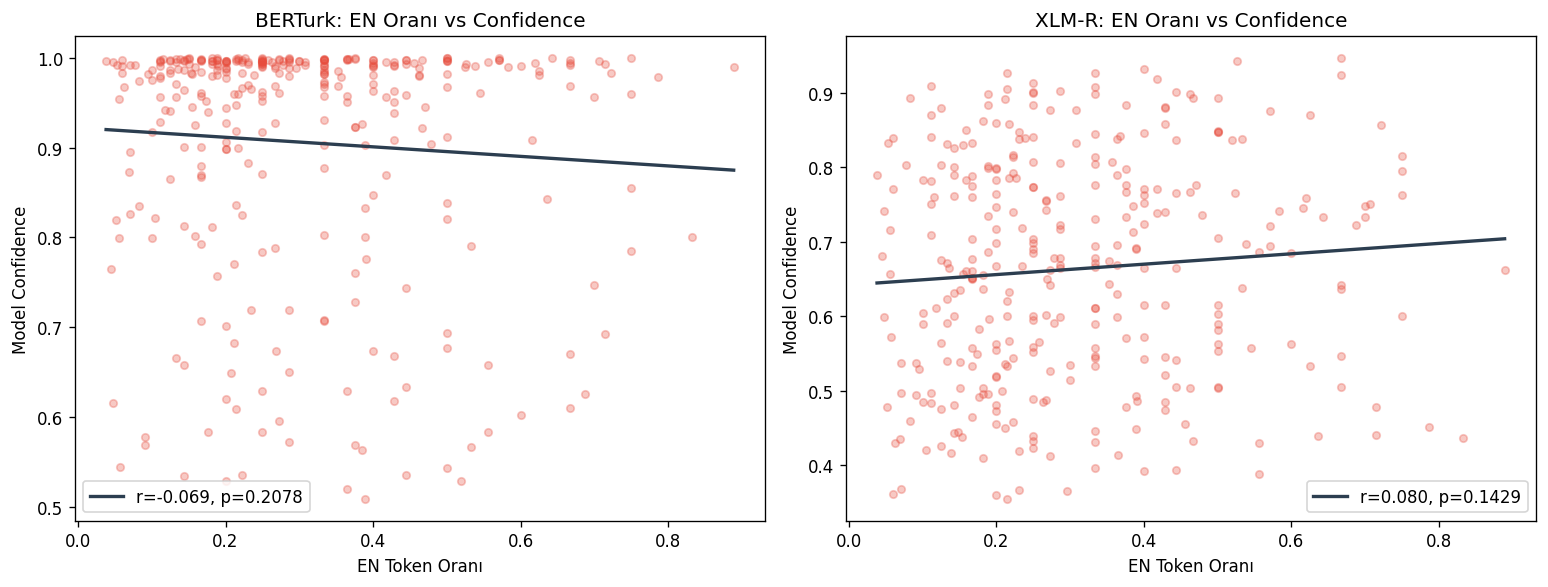

In [ ]:
# CELL 13 — C: EN Token Oranı vs Confidence Korelasyonu
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

cs_data = df_combined[df_combined["group"] == "code_switched"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (score_col, title) in zip(axes, [
    ("berturk_score", "BERTurk"),
    ("xlmr_score",    "XLM-R"),
]):
    x = cs_data["en_ratio"].values
    y = cs_data[score_col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)

    ax.scatter(x, y, alpha=0.3, color="#e74c3c", s=20)
    ax.plot(x_line, slope * x_line + intercept, color="#2c3e50", lw=2,
            label=f"r={r:.3f}, p={p:.4f}")
    ax.set_xlabel("EN Token Oranı")
    ax.set_ylabel("Model Confidence")
    ax.set_title(f"{title}: EN Oranı vs Confidence")
    ax.legend()

    print(f"{title}: r={r:.3f}, p={p:.4f}, slope={slope:.3f}")
    if p < 0.05:
        print(f"  → EN oranı arttıkça confidence {'düşüyor' if slope < 0 else 'yükseliyor'} (anlamlı)")
    else:
        print(f"  → Anlamlı korelasyon yok")

plt.tight_layout()
plt.savefig("en_ratio_vs_confidence.png", bbox_inches="tight")
plt.show()

SHAP hesaplanıyor (100 cümle)...


  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 2/100 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   4%|▍         | 4/100 [01:24<58:06, 36.32s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [1:30:45<00:00, 61.41s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [1:31:47, 55.63s/it]



EN token: n=626, mean=0.0166
TR token: n=2293, mean=0.0153
t=1.294, p=0.195814 (anlamsız)
→ EN token'lar modelin kararını daha çok etkiliyor


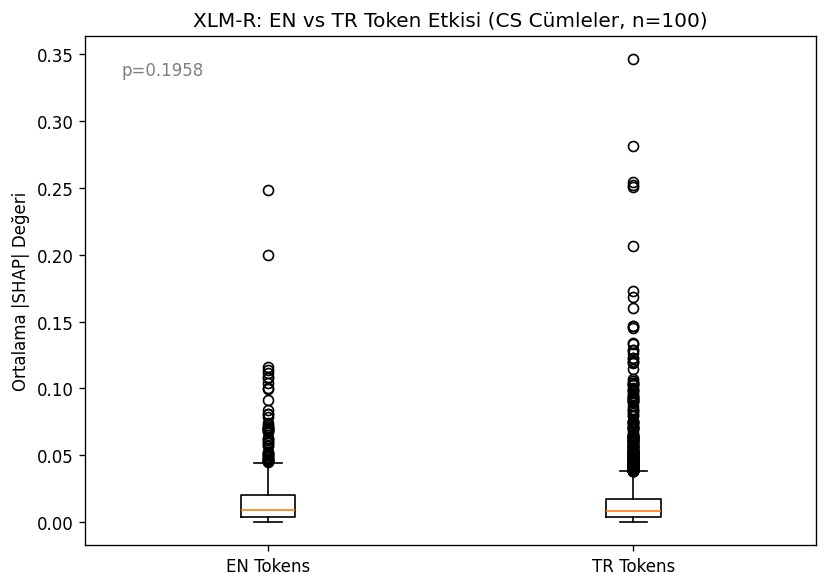

In [ ]:
# CELL 14 — D: SHAP EN vs TR Token Karşılaştırması
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# df_cs_full'dan tags'leri al
cs_texts = df_cs_full["text"].tolist()
cs_tags  = df_cs_full["tags"].tolist()

print("SHAP hesaplanıyor (100 cümle)...")
explainer   = shap.Explainer(predict_proba, xlmr_tokenizer)
shap_values = explainer(cs_texts[:100])

en_shap_vals, tr_shap_vals = [], []

for i in range(min(100, len(shap_values))):
    tags    = cs_tags[i]
    sv      = shap_values[i]
    word_ids = xlmr_tokenizer(
        cs_texts[i].split(), is_split_into_words=True
    ).word_ids()

    for tok_idx, word_id in enumerate(word_ids):
        if word_id is None or word_id >= len(tags):
            continue
        if tok_idx >= len(sv.values):
            continue
        shap_val = float(np.abs(sv.values[tok_idx]).mean())
        if tags[word_id] == "E":
            en_shap_vals.append(shap_val)
        elif tags[word_id] == "T":
            tr_shap_vals.append(shap_val)

t_stat, p_val = stats.ttest_ind(en_shap_vals, tr_shap_vals)
en_mean = np.mean(en_shap_vals)
tr_mean = np.mean(tr_shap_vals)

print(f"\nEN token: n={len(en_shap_vals)}, mean={en_mean:.4f}")
print(f"TR token: n={len(tr_shap_vals)}, mean={tr_mean:.4f}")
print(f"t={t_stat:.3f}, p={p_val:.6f} {'*** anlamlı' if p_val < 0.05 else '(anlamsız)'}")
higher = "EN" if en_mean > tr_mean else "TR"
print(f"→ {higher} token'lar modelin kararını daha çok etkiliyor")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([en_shap_vals, tr_shap_vals], labels=["EN Tokens", "TR Tokens"])
ax.set_ylabel("Ortalama |SHAP| Değeri")
ax.set_title("XLM-R: EN vs TR Token Etkisi (CS Cümleler, n=100)")
ax.text(0.05, 0.95, f"p={p_val:.4f}", transform=ax.transAxes,
        color="red" if p_val < 0.05 else "gray", fontsize=10, va="top")
plt.tight_layout()
plt.savefig("shap_en_vs_tr.png", bbox_inches="tight")
plt.show()

Sentence embedding modeli yükleniyor...


config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CS embeddings...
TR embeddings...


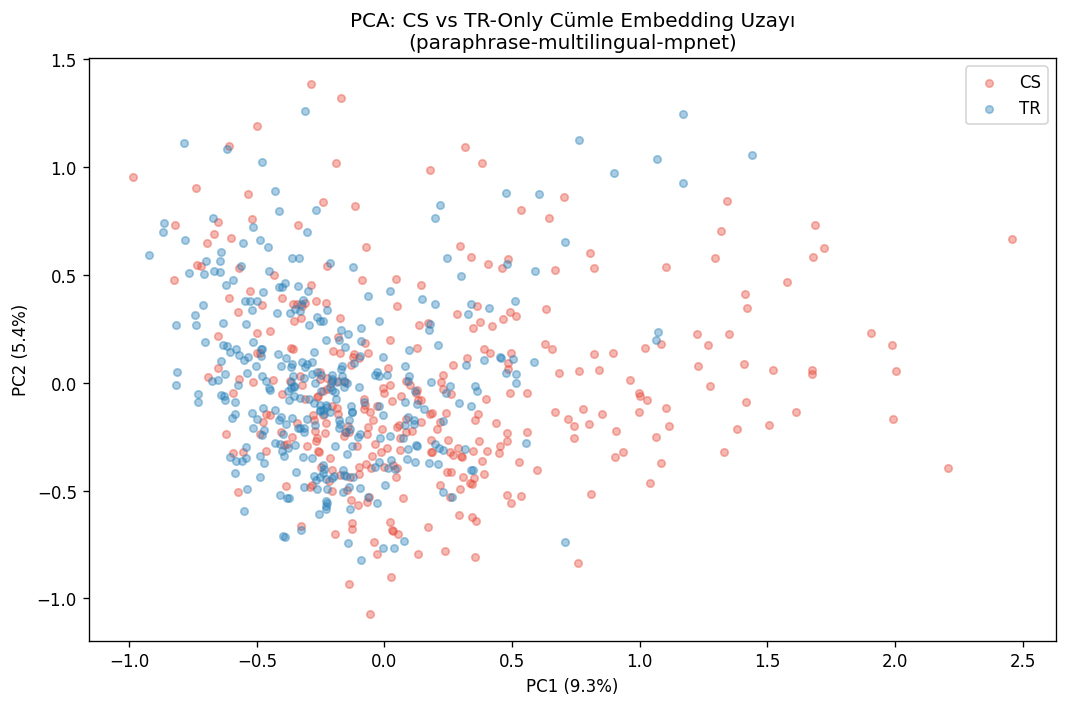


PCA uzayında CS-TR merkez mesafesi: 0.3833
PC1 varyans açıklama: 9.3%
PC2 varyans açıklama: 5.4%


In [ ]:
# CELL 15 — Sentence Embedding Analizi (PCA/t-SNE)
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Sentence embedding modeli yükleniyor...")
emb_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
emb_model     = AutoModel.from_pretrained("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
emb_model.eval()

def get_embeddings(texts, batch_size=32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc   = emb_tokenizer(batch, padding=True, truncation=True,
                               max_length=128, return_tensors="pt")
        with torch.no_grad():
            out = emb_model(**enc)
        # Mean pooling
        emb = out.last_hidden_state.mean(dim=1).numpy()
        all_embs.append(emb)
    return np.vstack(all_embs)

cs_texts = df_combined[df_combined["group"]=="code_switched"]["text"].tolist()
tr_texts = df_combined[df_combined["group"]=="turkish_only"]["text"].tolist()

print("CS embeddings...")
cs_embs = get_embeddings(cs_texts)
print("TR embeddings...")
tr_embs = get_embeddings(tr_texts)

all_embs   = np.vstack([cs_embs, tr_embs])
all_labels = ["CS"] * len(cs_embs) + ["TR"] * len(tr_embs)

# PCA
pca  = PCA(n_components=2)
proj = pca.fit_transform(all_embs)

fig, ax = plt.subplots(figsize=(9, 6))
for label, color in [("CS", "#e74c3c"), ("TR", "#2980b9")]:
    mask = [l == label for l in all_labels]
    ax.scatter(proj[mask, 0], proj[mask, 1],
               alpha=0.4, s=20, color=color, label=label)

ax.set_title("PCA: CS vs TR-Only Cümle Embedding Uzayı\n(paraphrase-multilingual-mpnet)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig("embedding_pca.png", bbox_inches="tight")
plt.show()

# İki grup merkezi arasındaki mesafe
cs_center = proj[[l=="CS" for l in all_labels]].mean(axis=0)
tr_center = proj[[l=="TR" for l in all_labels]].mean(axis=0)
dist = np.linalg.norm(cs_center - tr_center)
print(f"\nPCA uzayında CS-TR merkez mesafesi: {dist:.4f}")
print(f"PC1 varyans açıklama: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 varyans açıklama: {pca.explained_variance_ratio_[1]*100:.1f}%")

In [ ]:
# CELL 15 — Tüm Sonuçları Kaydet
df_combined.to_csv("cs_full_analysis.csv", index=False, encoding="utf-8-sig")

print("=== ÖZET BULGULAR ===")
cs = df_combined[df_combined["group"]=="code_switched"]
tr = df_combined[df_combined["group"]=="turkish_only"]
print(f"\n1. Confidence (CS vs TR-only):")
print(f"   BERTurk: {cs['berturk_score'].mean():.3f} vs {tr['berturk_score'].mean():.3f} (p=0.083)")
print(f"   XLM-R:   {cs['xlmr_score'].mean():.3f} vs {tr['xlmr_score'].mean():.3f} (p=0.002)")
print(f"\n2. EN oranı-confidence korelasyonu: anlamlı değil (her iki model)")
print(f"\n3. Token-level SHAP: EN vs TR fark yok (p=0.196)")
print(f"\n4. Embedding PCA: CS daha geniş dağılım, merkez mesafe=0.383")
print(f"\nKaydedildi: cs_full_analysis.csv")
print(f"Görseller: model_comparison.png, en_ratio_vs_confidence.png, shap_en_vs_tr.png, embedding_pca.png")

=== ÖZET BULGULAR ===

1. Confidence (CS vs TR-only):
   BERTurk: 0.906 vs 0.888 (p=0.083)
   XLM-R:   0.663 vs 0.627 (p=0.002)

2. EN oranı-confidence korelasyonu: anlamlı değil (her iki model)

3. Token-level SHAP: EN vs TR fark yok (p=0.196)

4. Embedding PCA: CS daha geniş dağılım, merkez mesafe=0.383

Kaydedildi: cs_full_analysis.csv
Görseller: model_comparison.png, en_ratio_vs_confidence.png, shap_en_vs_tr.png, embedding_pca.png
